# 01 · Vanilla SINDy

**SINDy** (Sparse Identification of Nonlinear Dynamics, Brunton et al. 2016):

1. Estimate the derivative $\dot X$ from the data (finite differences).
2. Build a candidate library $\Theta(X)$.
3. Solve $\dot X = \Theta(X)\,\Xi$ for a **sparse** $\Xi$ via sequentially-thresholded
   least squares (**STLSQ**): least squares, zero out small coefficients, repeat.

We use the **Lotka–Volterra** system, whose true equations are
$$\dot x = 1.0\,x - 0.1\,xy, \qquad \dot y = -1.5\,y + 0.075\,xy.$$

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

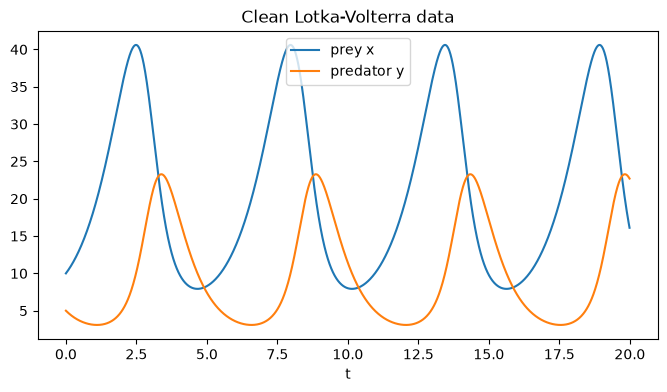

In [3]:
from sparse_demos import systems, plotting
import pysindy as ps

# Clean data first - SINDy is at its best here.
t, X = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01, noise_std=0.0)
dt = t[1] - t[0]
plotting.plot_trajectories(t, X, labels=["prey x", "predator y"],
                           title="Clean Lotka-Volterra data"); plt.show()

## Fit with pysindy

A degree-2 polynomial library plus an STLSQ optimizer with a coefficient threshold.

In [4]:
model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=2),
    optimizer=ps.STLSQ(threshold=0.05),
)
model.fit(X, t=dt, feature_names=["x", "y"])
print("Recovered model (clean data):")
model.print()
print("\nTrue model:\n(x)' = 1.000 x + -0.100 x y\n(y)' = -1.500 y + 0.075 x y")

Recovered model (clean data):
(x)' =  1.000 x + -0.100 x y
(y)' = -1.500 y +  0.075 x y

True model:
(x)' = 1.000 x + -0.100 x y
(y)' = -1.500 y + 0.075 x y


That is an essentially exact recovery. To demystify the optimizer, here is the same
idea implemented from scratch with the helpers in `sparse_demos.solvers`.

In [5]:
from sparse_demos import libraries, solvers

# Estimate derivatives by finite differences, build library, run STLSQ ourselves.
dXdt = np.gradient(X, dt, axis=0)
Theta, names = libraries.polynomial_library(X, degree=2)
Xi = solvers.stlsq(Theta, dXdt, threshold=0.05)
solvers.print_model(Xi, names, target_names=["x'", "y'"])

x' = +1.000 x0 -0.100 x0 x1
y' = -1.500 x1 +0.075 x0 x1


## The catch: noise

SINDy estimates $\dot X$ by differentiating the data — and differentiation
*amplifies noise*. Watch what a modest amount of measurement noise does.

In [6]:
tn, Xn = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01,
                          noise_std=0.5, seed=1)
noisy = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2),
                 optimizer=ps.STLSQ(threshold=0.05))
noisy.fit(Xn, t=dt, feature_names=["x", "y"])
print("Recovered model from NOISY data (std=0.5):")
noisy.print()
print("\n-> spurious terms creep in; at higher noise the model breaks entirely.")

Recovered model from NOISY data (std=0.5):
(x)' = -0.117 1 +  0.998 x + -0.099 x y
(y)' = -1.544 y +  0.076 x y

-> spurious terms creep in; at higher noise the model breaks entirely.


**Takeaway.** Vanilla SINDy is fast and exact on clean polynomial dynamics, but its
reliance on numerical derivatives makes it fragile to noise. Next: **Weak SINDy**
removes that derivative step. → `02_weak_sindy.ipynb`